In [1]:
# !pip install numpy
# !pip install matplotlib
# !pip install pandas
# !pip install xgboost
# !pip install scikit-learn
# !pip install lightgbm
# !pip install statsmodels
# !pip install plotly

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb
import lightgbm as lgb
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from lightgbm import LGBMRegressor


In [3]:
df_AQI_2021 = pd.read_csv("Air_Quality_Data/10_state_aqi_2021.csv")
df_AQI_2022 = pd.read_csv("Air_Quality_Data/10_state_aqi_2022.csv")
df_AQI_2023 = pd.read_csv("Air_Quality_Data/10_state_aqi_2023.csv")
df_US_Counties = pd.read_csv("(2B)uscounties.csv")

In [4]:
df_AQI = pd.concat([df_AQI_2021, df_AQI_2022, df_AQI_2023])

df_AQI

,State Name,county Name,State Code,County Code,Date,AQI,Category,Defining Parameter,Defining Site,Number of Sites Reporting,Created,Last Updated
0,Alaska,Aleutians East,2,13,2021-01-01,7,Good,PM2.5,02-013-0002,1,2021-01-01 16:30:00,2021-12-31 23:12:00
1,Alaska,Aleutians East,2,13,2021-01-04,8,Good,PM2.5,02-013-0002,1,2021-01-04 16:30:00,2021-12-31 23:12:00
2,Alaska,Aleutians East,2,13,2021-01-07,11,Good,PM2.5,02-013-0002,1,2021-01-07 16:30:00,2021-12-31 23:12:00
3,Alaska,Aleutians East,2,13,2021-01-10,4,Good,PM2.5,02-013-0002,1,2021-01-10 16:30:00,2021-12-31 23:12:00
4,Alaska,Aleutians East,2,13,2021-01-13,4,Good,PM2.5,02-013-0002,1,2021-01-13 16:30:00,2021-12-31 23:12:00
...,...,...,...,...,...,...,...,...,...,...,...,...
64985,Virginia,Caroline,51,33,06-07-2023,21,Good,Ozone,51-033-0001,1,2023-07-06 16:30:00,2023-12-31 23:42:00
64986,Virginia,Caroline,51,33,07-07-2023,9,Good,Ozone,51-033-0001,1,2023-07-07 16:30:00,2023-12-31 23:42:00
64987,Virginia,Caroline,51,33,08-07-2023,18,Good,Ozone,51-033-0001,1,2023-07-08 16:30:00,2023-12-31 23:42:00
64988,Virginia,Caroline,51,33,09-07-2023,7,Good,Ozone,51-033-0001,1,2023-07-09 16:30:00,2023-12-31 23:42:00


In [5]:
def create_year_quarter_df(df):
    df['Date'] = pd.to_datetime(df['Date'], format='mixed')
    df['dayofweek'] = df['Date'].dt.dayofweek
    df['quarter'] = df['Date'].dt.quarter
    df['month'] = df['Date'].dt.month
    df['year'] = df['Date'].dt.year
    df['dayofyear'] = df['Date'].dt.dayofyear
    df['dayofmonth'] = df['Date'].dt.day
    df['weekofyear'] = df['Date'].dt.isocalendar().week  # For week of year
    return df

In [6]:
df_AQI_Cali = df_AQI[df_AQI['State Name'] == 'California']
# Mean of AQI for California in a day
df_AQI_Cali_avg = df_AQI_Cali.groupby(['Date'])['AQI'].mean().reset_index()
df_AQI_Cali_avg = df_AQI_Cali_avg.sort_values(by='Date')

df_AQI_Cali_avg

,Date,AQI
0,01-01-2023,63.450980
1,01-02-2023,65.156863
2,01-03-2023,63.580000
3,01-04-2023,53.294118
4,01-05-2023,53.115385
...,...,...
1090,31-05-2023,53.942308
1091,31-07-2023,56.403846
1092,31-08-2023,49.288462
1093,31-10-2023,67.440000


In [7]:
df_AQI_Cali_avg = create_year_quarter_df(df_AQI_Cali_avg)
df_AQI_Cali_avg = df_AQI_Cali_avg.sort_values(by='Date')


In [8]:
df_AQI_Cali_avg

,Date,AQI,dayofweek,quarter,month,year,dayofyear,dayofmonth,weekofyear
240,2021-01-01,65.377358,4,1,1,2021,1,1,53
241,2021-01-02,56.905660,5,1,1,2021,2,2,53
242,2021-01-03,59.000000,6,1,1,2021,3,3,53
243,2021-01-04,51.452830,0,1,1,2021,4,4,1
244,2021-01-05,50.018868,1,1,1,2021,5,5,1
...,...,...,...,...,...,...,...,...,...
1053,2023-12-27,43.078431,2,4,12,2023,361,27,52
1065,2023-12-28,54.627451,3,4,12,2023,362,28,52
1076,2023-12-29,64.196078,4,4,12,2023,363,29,52
1087,2023-12-30,70.431373,5,4,12,2023,364,30,52


In [9]:
# XGBRegressor
from xgboost import XGBRegressor
# mean_absolute_error
from sklearn.metrics import mean_absolute_error
# product
from itertools import product

In [10]:
# Convert Date to datetime format
df_AQI_Cali_avg['Date'] = pd.to_datetime(df_AQI_Cali_avg['Date'],format ='mixed')

# Set Date as the index
df_AQI_Cali_avg.set_index('Date', inplace=True)

# Model XGBoost

Best Parameters: {'n_estimators': 500, 'learning_rate': 0.01, 'max_depth': 6, 'subsample': 0.8, 'colsample_bytree': 1.0}
Best Mean Squared Error (MSE): 73.91120528538245
Mean Absolute Error (MAE): 6.276672990113475


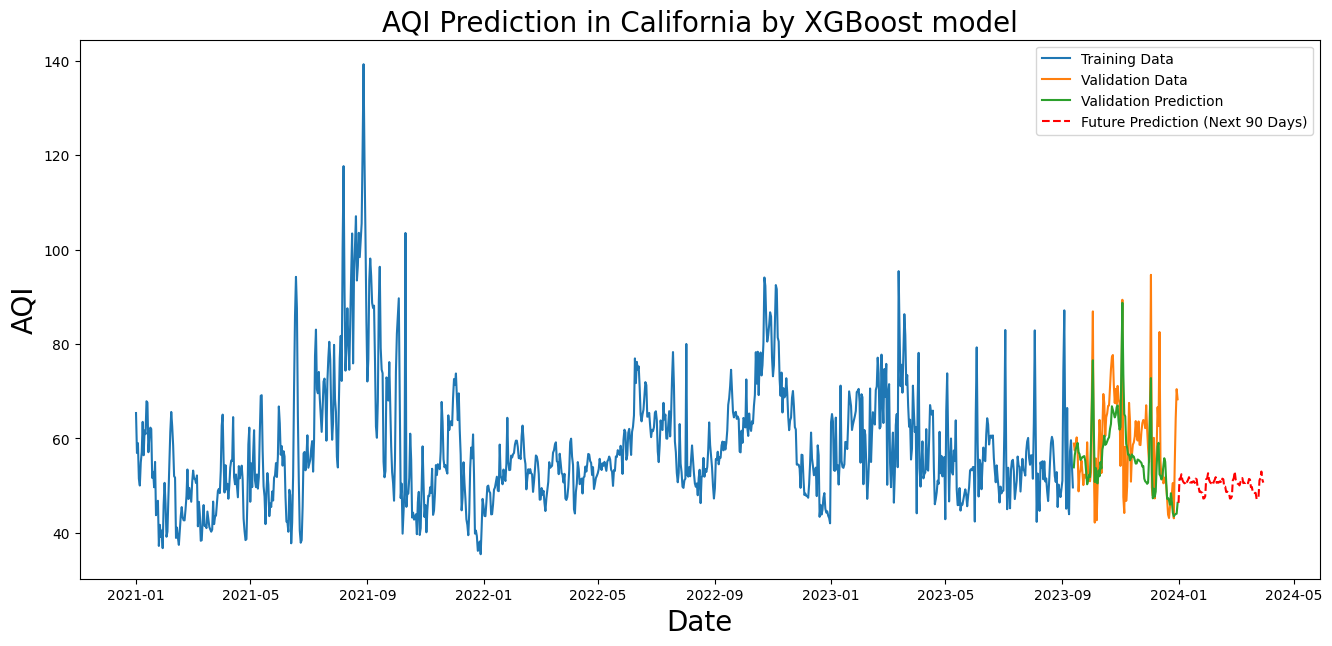

In [11]:
# Features (X) and target (y)
feature_cols = ["year", "quarter", "month", "dayofyear", "dayofmonth", "weekofyear", "dayofweek"]
X = df_AQI_Cali_avg[feature_cols]
y = df_AQI_Cali_avg['AQI']

# Split the data into training and testing sets (90% train, 10% test)
train_size = int(len(X) * 0.9)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Hyperparameter tuning grid
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 6, 9],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Find the best parameters
best_mse = float("inf")
best_params = {}
results = []

for params in product(
    param_grid['n_estimators'], 
    param_grid['learning_rate'], 
    param_grid['max_depth'], 
    param_grid['subsample'], 
    param_grid['colsample_bytree']
):
    n_estimators, learning_rate, max_depth, subsample, colsample_bytree = params
    model = XGBRegressor(
        objective='reg:squarederror',
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'mse': mse,
        'mae': mae
    })
    if mse < best_mse:
        best_mse = mse
        best_params = {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree
        }

# Train the best model
model = XGBRegressor(
    objective='reg:squarederror',
    **best_params,
    random_state=42
)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Best Parameters:", best_params)
print("Best Mean Squared Error (MSE):", best_mse)
print("Mean Absolute Error (MAE):", mae)

# Predicting for the next 90 days
future_predictions = []
current_row = X_test.iloc[-1].copy()
future_dates = pd.date_range(start=df_AQI_Cali_avg.index[-1], periods=91, freq='D')[1:]

for date in future_dates:
    pred = model.predict(np.array(current_row).reshape(1, -1))[0]
    future_predictions.append(pred)
    current_row['dayofmonth'] += 1
    if current_row['dayofmonth'] > 28:
        current_row['dayofmonth'] = 1
        current_row['month'] += 1
        if current_row['month'] > 12:
            current_row['month'] = 1
            current_row['year'] += 1

# Create DataFrame for future predictions
future_90 = pd.DataFrame({'Date': future_dates, 'AQI': future_predictions})

# Plotting
plt.figure(figsize=(16, 7))
plt.plot(df_AQI_Cali_avg.index[:train_size], y_train, label='Training Data')
plt.plot(df_AQI_Cali_avg.index[train_size:], y_test, label='Validation Data')
plt.plot(df_AQI_Cali_avg.index[train_size:], y_pred, label='Validation Prediction')
plt.plot(future_90['Date'], future_90['AQI'], color='red', linestyle='--', label='Future Prediction (Next 90 Days)')
plt.xlabel('Date', size=20)
plt.ylabel('AQI', size=20)
plt.title('AQI Prediction in California by XGBoost model', size=20)
plt.legend()
plt.show()


# LGBM

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000035 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 985, number of used features: 7
[LightGBM] [Info] Start training from score 58.119915
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 985, number of used features: 7
[LightGBM] [Info] Start training from score 58.119915
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000100 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 985, 

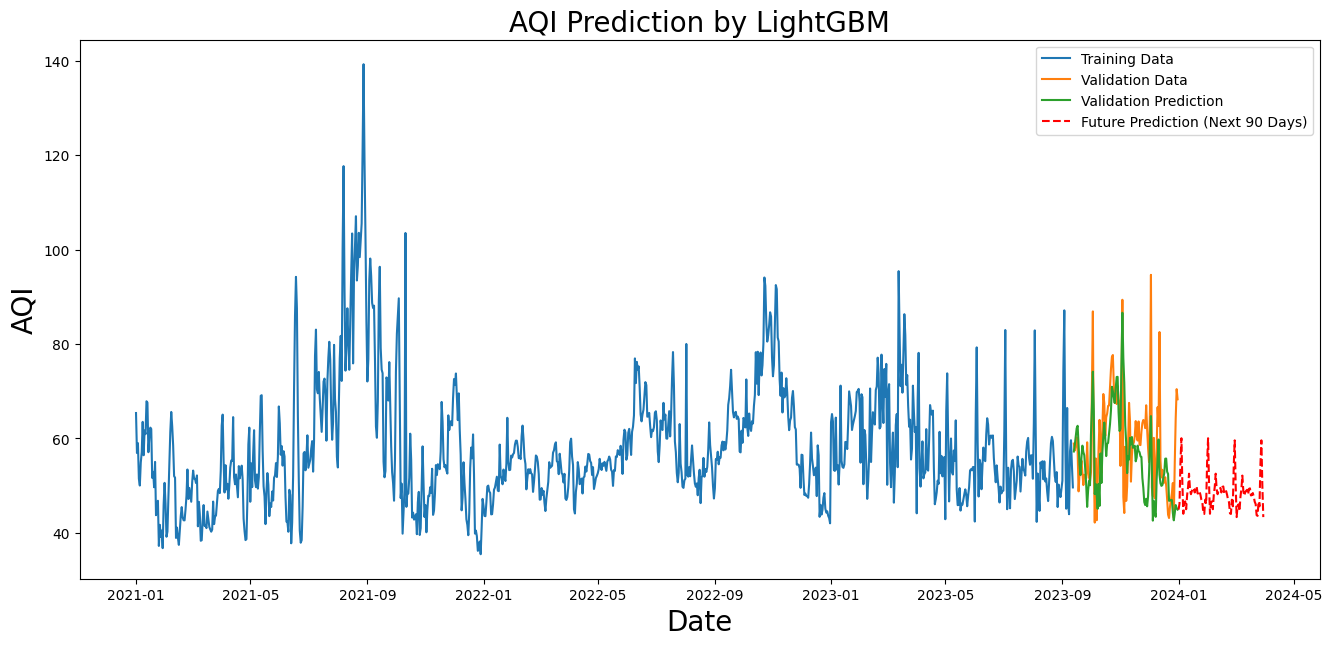

In [12]:
# Features (X) and target (y)
feature_cols = ["year", "quarter", "month", "dayofyear", "dayofmonth", "weekofyear", "dayofweek"]
X = df_AQI_Cali_avg[feature_cols]
y = df_AQI_Cali_avg['AQI']

# Split the data into training and testing sets (90% train, 10% test)
train_size = int(len(X) * 0.9)
X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

# Hyperparameter tuning grid
param_grid = {
    'n_estimators': [100, 500, 1000],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [-1, 6, 9],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Find the best parameters
best_mse = float("inf")
best_params = {}
results = []

for params in product(
    param_grid['n_estimators'], 
    param_grid['learning_rate'], 
    param_grid['max_depth'], 
    param_grid['subsample'], 
    param_grid['colsample_bytree']
):
    n_estimators, learning_rate, max_depth, subsample, colsample_bytree = params
    model = LGBMRegressor(
        n_estimators=n_estimators,
        learning_rate=learning_rate,
        max_depth=max_depth,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        random_state=42
    )
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'max_depth': max_depth,
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'mse': mse,
        'mae': mae
    })
    if mse < best_mse:
        best_mse = mse
        best_params = {
            'n_estimators': n_estimators,
            'learning_rate': learning_rate,
            'max_depth': max_depth,
            'subsample': subsample,
            'colsample_bytree': colsample_bytree
        }

# Train the best model
model = LGBMRegressor(
    **best_params,
    random_state=42
)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("Best Parameters:", best_params)
print("Best Mean Squared Error (MSE):", best_mse)
print("Mean Absolute Error (MAE):", mae)

# Predicting for the next 90 days
future_predictions = []
current_row = X_test.iloc[-1].copy()
future_dates = pd.date_range(start=df_AQI_Cali_avg.index[-1], periods=91, freq='D')[1:]

for date in future_dates:
    pred = model.predict(np.array(current_row).reshape(1, -1))[0]
    future_predictions.append(pred)
    current_row['dayofmonth'] += 1
    if current_row['dayofmonth'] > 28:
        current_row['dayofmonth'] = 1
        current_row['month'] += 1
        if current_row['month'] > 12:
            current_row['month'] = 1
            current_row['year'] += 1

# Create DataFrame for future predictions
future_90 = pd.DataFrame({'Date': future_dates, 'AQI': future_predictions})

# Plotting
plt.figure(figsize=(16, 7))
plt.plot(df_AQI_Cali_avg.index[:train_size], y_train, label='Training Data')
plt.plot(df_AQI_Cali_avg.index[train_size:], y_test, label='Validation Data')
plt.plot(df_AQI_Cali_avg.index[train_size:], y_pred, label='Validation Prediction')
plt.plot(future_90['Date'], future_90['AQI'], color='red', linestyle='--', label='Future Prediction (Next 90 Days)')
plt.xlabel('Date', size=20)
plt.ylabel('AQI', size=20)
plt.title('AQI Prediction by LightGBM', size=20)
plt.legend()
plt.show()


# Model Holt-Winters

In [13]:
# import ExponentialSmoothing
from statsmodels.tsa.holtwinters import ExponentialSmoothing

Training Holt-Winters model with seasonal_periods=100


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


For seasonal_periods=100, MSE: 155.2637365961712, MAE: 9.743181844446795
Training Holt-Winters model with seasonal_periods=120


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


For seasonal_periods=120, MSE: 127.79968252576599, MAE: 8.278964501593768
Training Holt-Winters model with seasonal_periods=140


...

For seasonal_periods=260, MSE: 157.11346169119454, MAE: 9.62469708629692
Training Holt-Winters model with seasonal_periods=280


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


For seasonal_periods=280, MSE: 256.9625696912686, MAE: 12.143641653195486

All configurations with their MSE and MAE values:
    seasonal_periods         mse        mae
0               100  155.263737   9.743182
1               120  127.799683   8.278965
2               140  189.274982  11.294368
3               160  143.750067   9.036341
4               180  306.021254  14.568615
5               200  110.728421   8.053757
6               220  166.593414  10.067568
7               240  175.120066   9.917465
8               260  157.113462   9.624697
9               280  256.962570  12.143642
Best seasonal_periods: 200.0


c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


MSE value on validation set: 110.72842120902783
MAE value on validation set: 8.05375659366648


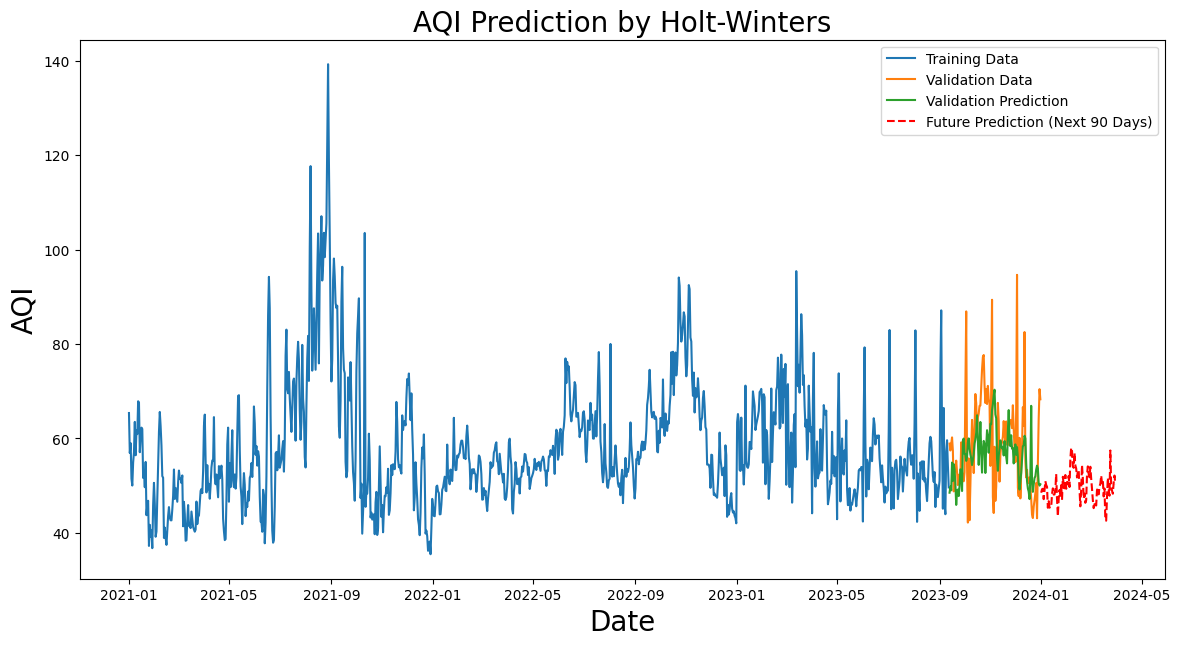

In [14]:
# Split the data into training and testing sets (90% train, 10% test)
shape = df_AQI_Cali_avg.shape[0]
train_set = df_AQI_Cali_avg[:int(shape * 0.9)]
valid_set = df_AQI_Cali_avg[int(shape * 0.9):]

# Training and Validation Data
training = train_set['AQI']
validation = valid_set['AQI']

# List of seasonal_periods to try
seasonal_periods_list = np.arange(100, 300, 20).tolist()
results = []

# Iterate over different seasonal_periods
for seasonal_periods in seasonal_periods_list:
    print(f'Training Holt-Winters model with seasonal_periods={seasonal_periods}')
    
    # Holt-Winters model fitting
    model = ExponentialSmoothing(training, seasonal='add', seasonal_periods=seasonal_periods, trend='add', damped_trend=True)
    model_fit = model.fit(optimized=True)    
        # Predicting for validation period + 90 days
    total_forecast_period = len(valid_set) + 90
    forecast = model_fit.forecast(steps=total_forecast_period)
    
    # Separate the forecast into validation and future
    forecast_valid = forecast[:len(valid_set)]
    forecast_future = forecast[len(valid_set):]
    
    # Create DataFrames for the forecasts
    forecast_valid_df = pd.DataFrame(forecast_valid, index=valid_set.index, columns=['Prediction'])
    future_forecast_df = pd.DataFrame(forecast_future, index=pd.date_range(start=valid_set.index[-1] + pd.Timedelta(days=1), periods=90), columns=['Prediction'])
    # Calculate MSE and MAE on the validation set
    mse = np.mean(np.square(np.array(validation) - np.array(forecast_valid_df['Prediction'])))
    mae = np.mean(np.abs(np.array(validation) - np.array(forecast_valid_df['Prediction'])))
    
    # Store results for comparison
    results.append({
        'seasonal_periods': seasonal_periods,
        'mse': mse,
        'mae': mae
    })
    
    print(f'For seasonal_periods={seasonal_periods}, MSE: {mse}, MAE: {mae}')

# Convert results to DataFrame for analysis
results_df = pd.DataFrame(results)
# Print all configurations with MSE and MAE
print("\nAll configurations with their MSE and MAE values:\n", results_df)

# Plot the forecast for the best seasonal_periods
best_seasonal_periods = results_df.sort_values('mse').iloc[0]['seasonal_periods']
print(f"Best seasonal_periods: {best_seasonal_periods}")

# Refit model with best seasonal_periods
model = ExponentialSmoothing(training, seasonal='add', seasonal_periods=int(best_seasonal_periods), trend='add', damped_trend=True)
model_fit = model.fit(optimized=True)

# Predicting for validation period + 90 days
total_forecast_period = len(valid_set) + 90
forecast = model_fit.forecast(steps=total_forecast_period)

# Separate the forecast into validation and future
forecast_valid = forecast[:len(valid_set)]
forecast_future = forecast[len(valid_set):]

# Create DataFrames for the forecasts
forecast_valid_df_AQI_avg_California = pd.DataFrame(forecast_valid, index=valid_set.index, columns=['Prediction'])
future_forecast_df_AQI_avg_California = pd.DataFrame(forecast_future, index=pd.date_range(start=valid_set.index[-1] + pd.Timedelta(days=1), periods=90), columns=['Prediction'])

# Calculate MSE and MAE on the validation set
mse = np.mean(np.square(np.array(validation) - np.array(forecast_valid_df_AQI_avg_California['Prediction'])))
mae = np.mean(np.abs(np.array(validation) - np.array(forecast_valid_df_AQI_avg_California['Prediction'])))

# Print evaluation metrics
print("MSE value on validation set:", mse)
print("MAE value on validation set:", mae)

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(train_set['AQI'], label='Training Data')
plt.plot(valid_set['AQI'], label='Validation Data')
plt.plot(forecast_valid_df_AQI_avg_California['Prediction'], label='Validation Prediction')
plt.plot(future_forecast_df_AQI_avg_California['Prediction'], color='red', linestyle='--', label='Future Prediction (Next 90 Days)')
plt.xlabel('Date', size=20)
plt.ylabel('AQI', size=20)
plt.title('AQI Prediction by Holt-Winters', size=20)
plt.legend()
plt.show()